<a href="https://colab.research.google.com/github/Tselovanska/machine-learning-course/blob/main/HW_2_2_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [13]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import drive

from sklearn.linear_model import Ridge, Lasso, ElasticNet
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
]


import operator


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Area under ROC score on Train dataset: 0.90


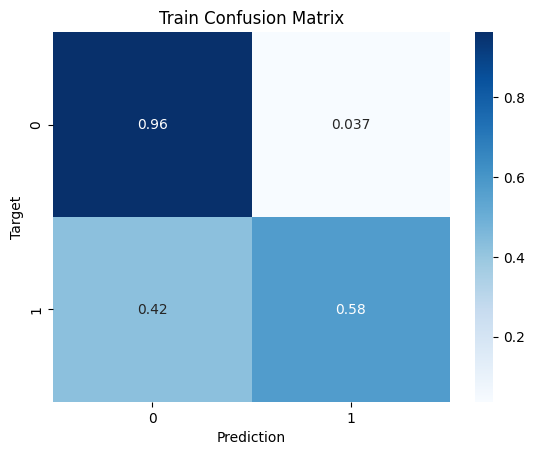

Area under ROC score on Validation dataset: 0.88


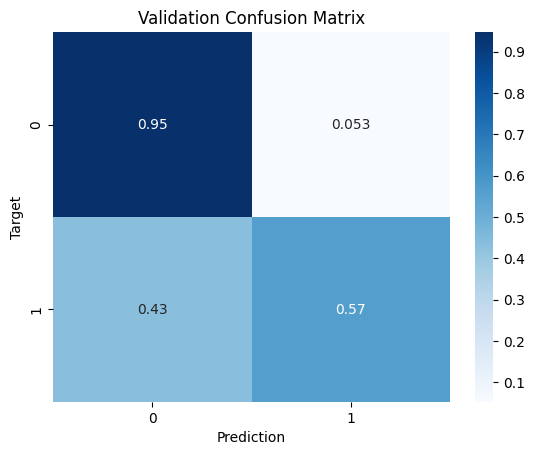

['hw_pipeline.joblib']

In [16]:
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

df = pd.read_csv(folder_path + file_name)

df.columns = df.columns.str.lower()

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['exited']
)

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns.drop('exited'))
target_col = 'exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]        # для roc_auc_score
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train' )
val_preds = predict_and_plot(model_pipeline,val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'hw_pipeline.joblib')



**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Area under ROC score on Train dataset: 0.94


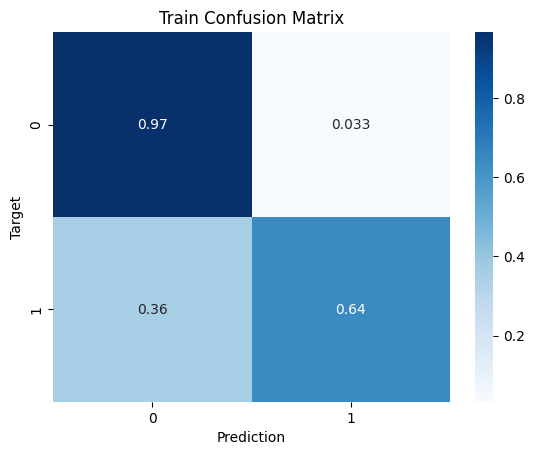

Area under ROC score on Validation dataset: 0.92


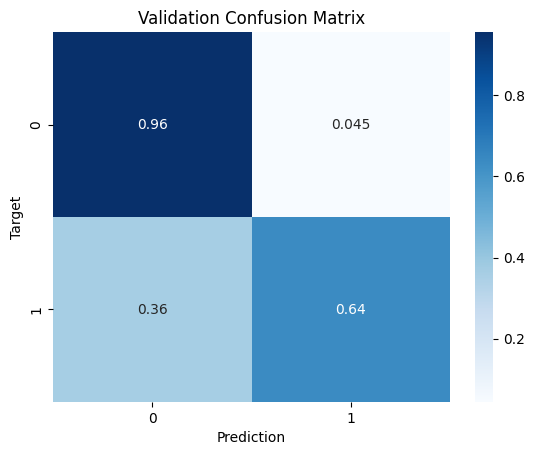

['hw_pipeline.joblib']

In [19]:


drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

df = pd.read_csv(folder_path + file_name)

df.columns = df.columns.str.lower()

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['exited']
)

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns.drop('exited'))
target_col = 'exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()



# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]        # для roc_auc_score
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train' )
val_preds = predict_and_plot(model_pipeline,val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'hw_pipeline.joblib')

- AUROC зріс з 0.88 до 0.92 (val), recall класу 1 з 0.57 до 0.64 - реальне покращення, не шум
- Overfit відсутній: розрив train/val (0.94 vs 0.92) практично такий самий, як був у лінійній моделі — poly-фічі не "перетренували" модель

Висновок: модель добре генералізує, лінійна межа логрегресії дійсно була вузьким місцем, квадратичні взаємодії дали користь

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Area under ROC score on Train dataset: 0.95


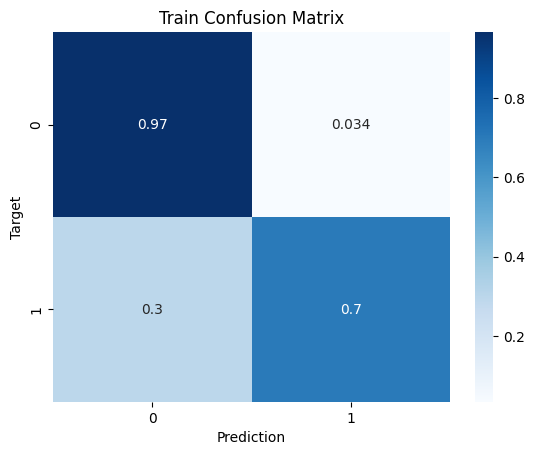

Area under ROC score on Validation dataset: 0.93


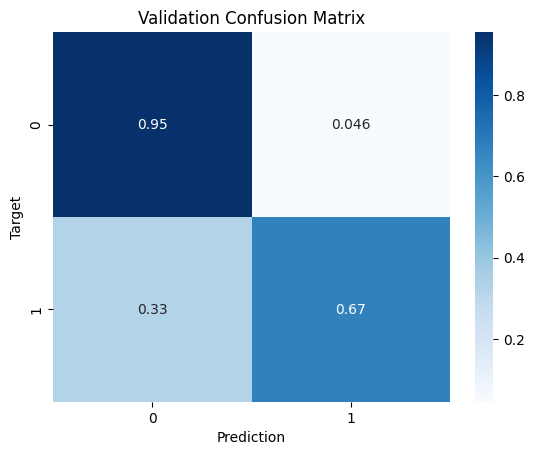

['hw_pipeline.joblib']

In [20]:

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

df = pd.read_csv(folder_path + file_name)

df.columns = df.columns.str.lower()

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['exited']
)

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns.drop('exited'))
target_col = 'exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()



# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]        # для roc_auc_score
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train' )
val_preds = predict_and_plot(model_pipeline,val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'hw_pipeline_2.joblib')

найвищий AUROC з трьох експериментів (0.93 val), але ціною початку розходження на recall. Модель ще узагальнює прийнятно (AUROC не впав, а зріс), проте це вже точка, де додаткова складність (більше поліноміальних ознак) починає давати менше приросту якості й більше підлаштування під шум train.

In [22]:
# Зчитуємо test дані
test_raw_df = pd.read_csv('test.csv')
test_raw_df.columns = test_raw_df.columns.str.lower()

missing = [c for c in input_cols if c not in test_raw_df.columns]
print("Відсутні колонки:", missing)

test_inputs = test_raw_df[input_cols].copy()


test_probs = model_pipeline.predict_proba(test_inputs)[:, 1]

# Формуємо submission
submission_df = pd.read_csv('sample_submission.csv')
submission_df["Exited"] = test_probs

submission_df.to_csv("submission_poly4.csv", index=False)
submission_df.head()

Відсутні колонки: []


,id,Exited
0,15000,0.047115
1,15001,0.028159
2,15002,0.014796
3,15003,0.399338
4,15004,0.011627


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [23]:
df = pd.read_csv('regression_data (1).csv')
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [28]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42,
)

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns.drop('target'))
target_col = 'target'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',  LinearRegression())
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)


def evaluate_regression(model_pipeline, inputs, targets, name=""):
    preds = model_pipeline.predict(inputs)
    r2 = r2_score(targets, preds)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    print(f"{name} — R2: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    return preds

train_preds = evaluate_regression(model_pipeline, train_inputs, train_targets, "Train")
test_preds = evaluate_regression(model_pipeline, test_inputs, test_targets, "Test")

Train — R2: 1.0000, MAE: 0.00, RMSE: 0.00
Test — R2: 0.8710, MAE: 10.83, RMSE: 17.35


Відбувся overfit, Модель ідеально запам'ятала кожну точку, але в RMSE  на тестувальних данниї почала припускатись значних помилок.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [29]:


warnings.filterwarnings("ignore")



train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42,
)

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns.drop('target'))
target_col = 'target'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=20, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


def evaluate_regression(model_pipeline, inputs, targets, name=""):
    preds = model_pipeline.predict(inputs)
    r2 = r2_score(targets, preds)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    print(f"{name} — R2: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    return dict(r2=r2, mae=mae, rmse=rmse)

results = []

for model in models:
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    model_pipeline.fit(train_inputs, train_targets)

    print(f"=== {model} ===")
    train_metrics = evaluate_regression(model_pipeline, train_inputs, train_targets, "Train")
    test_metrics = evaluate_regression(model_pipeline, test_inputs, test_targets, "Test")
    print()

    results.append({
        'model': str(model),
        'r2_train': train_metrics['r2'],
        'r2_test': test_metrics['r2'],
        'gap_r2': train_metrics['r2'] - test_metrics['r2'],
        'rmse_train': train_metrics['rmse'],
        'rmse_test': test_metrics['rmse'],
    })

results_df = pd.DataFrame(results)
results_df

=== LinearRegression() ===
Train — R2: 1.0000, MAE: 0.00, RMSE: 0.00
Test — R2: 0.9305, MAE: 6.84, RMSE: 12.73

=== Ridge() ===
Train — R2: 0.9822, MAE: 4.01, RMSE: 5.89
Test — R2: 0.9789, MAE: 5.52, RMSE: 7.02

=== Lasso() ===
Train — R2: 0.9867, MAE: 4.03, RMSE: 5.10
Test — R2: 0.9862, MAE: 4.70, RMSE: 5.67

=== ElasticNet() ===
Train — R2: 0.5369, MAE: 24.39, RMSE: 30.03
Test — R2: 0.6028, MAE: 26.11, RMSE: 30.44



,model,r2_train,r2_test,gap_r2,rmse_train,rmse_test
0,LinearRegression(),1.000000,0.930495,0.069505,6.469539e-13,12.734214
1,Ridge(),0.982219,0.978871,0.003348,5.885065e+00,7.021050
2,Lasso(),0.986656,0.986211,0.000445,5.098171e+00,5.671931
3,ElasticNet(),0.536883,0.602780,-0.065897,3.003453e+01,30.442414


In [30]:
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])
lasso_pipeline.fit(train_inputs, train_targets)

feature_names = lasso_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = lasso_pipeline.named_steps['regressor'].coef_.flatten()

coefs_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
zero_count = (coefs_df['coef'] == 0).sum()
total = len(coefs_df)

print(f"Занулено {zero_count} з {total} ознак ({zero_count/total*100:.1f}%)")
coefs_df[coefs_df['coef'] != 0].sort_values('coef', key=abs, ascending=False).head(15)

Занулено 53128 з 53129 ознак (100.0%)


,feature,coef
3,num__feature_4,194.929248


Додатковий аналіз коефіцієнтів підтверджує це: Lasso занулила 53128 з 53129 поліноміальних ознак (100%), залишивши лише feature_4 у первинному (нестепеневому) вигляді. Це означає, що справжня залежність у даних — проста лінійна функція від однієї ознаки, а всі поліноміальні комбінації до степеня 20 — шум. Саме тому Ridge (яка лише зменшує вагу шумових ознак, але не усуває їх) поступається Lasso: вона все ще "тримає" тисячі непотрібних коефіцієнтів, тоді як Lasso їх прибирає повністю.